# Интеллектуальный анализ данных – весна 2026
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:
df = pd.read_csv('tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
26199,35896,80848,USA,07-04-2020,Glad to see #N95 listings totally removed from...,Extremely Positive
222,4067,49019,NaN,16-03-2020,Korea - 8200++ Covid-19 cases \r\r\nMalaysia -...,Negative
31374,42396,87348,Unknown,11-04-2020,?@mysteriousuniv? ?@ConspiracyStuff? ?@billhan...,Negative
5883,10942,55894,"Michigan, USA",19-03-2020,Guess what guys?! At the supermarket I saw the...,Extremely Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df_binary = df.copy()
df_binary['Sentiment'].value_counts(dropna=False)

Sentiment
Positive              11422
Negative               9917
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64

In [4]:
df_binary['Sentiment'] = df_binary['Sentiment'].map({
    'Positive': 1,
    'Extremely Positive': 1,
    'Negative': 0,
    'Extremely Negative': 0
})
df_binary['Sentiment'].value_counts(dropna=False)

Sentiment
1    18046
0    15398
Name: count, dtype: int64

Сбалансированы ли классы?

In [5]:
df_binary['Sentiment'].value_counts(normalize=True)

Sentiment
1    0.539589
0    0.460411
Name: proportion, dtype: float64

**Ответ:** Я решила посмотреть в процентах, и получилось 54/46, что говорит о том, что классы сбалансированы, доли положительного и отрицательного классов примерно равны 

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [6]:
df_binary.isna().sum()

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [7]:
df_binary = df_binary.fillna('Unknown')
df_binary

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,Unknown,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,Unknown,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
...,...,...,...,...,...,...
33439,44949,89901,OHIO,14-04-2020,I never that weÃÂd be in a situation &amp; w...,1
33440,44950,89902,Unknown,14-04-2020,@MrSilverScott you are definitely my man. I fe...,1
33441,44952,89904,Unknown,14-04-2020,Response to complaint not provided citing COVI...,0
33442,44953,89905,Unknown,14-04-2020,You know itÃÂs getting tough when @KameronWi...,1


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df_binary,
    test_size=0.3,
    random_state=0,
    stratify=df_binary['Sentiment']
)

train = train.copy()
test = test.copy()

y_train = train['Sentiment']
y_test = test['Sentiment']

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [9]:
from collections import Counter

voc = Counter()

for text in train['OriginalTweet']:
    tokens = text.lower().split()
    voc.update(tokens)

voc

Counter({'the': 26708,
         'to': 23432,
         'and': 14535,
         'of': 13123,
         'a': 11754,
         'in': 11291,
         'for': 8571,
         '#coronavirus': 8222,
         'is': 7411,
         'are': 7020,
         'on': 5446,
         'you': 5353,
         'i': 5314,
         'at': 4652,
         'this': 4603,
         'with': 4079,
         'prices': 3906,
         'food': 3804,
         'we': 3780,
         'that': 3743,
         'have': 3712,
         'as': 3691,
         'be': 3502,
         'grocery': 3442,
         'supermarket': 3250,
         'covid-19': 3188,
         'from': 3168,
         'store': 3142,
         'people': 3113,
         'it': 3091,
         'all': 2867,
         'your': 2805,
         'not': 2670,
         'will': 2643,
         'our': 2526,
         'my': 2505,
         '#covid19': 2473,
         'they': 2345,
         'consumer': 2288,
         'has': 2279,
         'by': 2274,
         'can': 2229,
         '&amp;': 2225,
         

Какой размер словаря получился?

In [10]:
len(voc)

80027

Размер словаря 80027 уникальных токенов

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [11]:
voc.most_common(10)

[('the', 26708),
 ('to', 23432),
 ('and', 14535),
 ('of', 13123),
 ('a', 11754),
 ('in', 11291),
 ('for', 8571),
 ('#coronavirus', 8222),
 ('is', 7411),
 ('are', 7020)]

**Ответ:** В топ-10 вошли эти токеры 'the', 'to', 'and', 'of', 'a', 'in', 'for', 'is', 'are'. Они оказались в топе, так как часто используются почти в любых английских предложениях, но сами по себе несут мало смысла для анализа тональности.  Ещё в топ попал токен 'coronavirus', так как датасет посвящён твитам о коронавирусе.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

vocab_without_stopwords = Counter({
    token: count
    for token, count in voc.items()
    if token not in stop_words
})

vocab_without_stopwords.most_common(10)

[nltk_data] Downloading package stopwords to /Users/alisa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('#coronavirus', 8222),
 ('prices', 3906),
 ('food', 3804),
 ('grocery', 3442),
 ('supermarket', 3250),
 ('covid-19', 3188),
 ('store', 3142),
 ('people', 3113),
 ('#covid19', 2473),
 ('consumer', 2288)]

**Ответ:**  После удаления стоп-слов топ стал более понятным, теперь нет предлогов и союзов.  Теперь тут более тематические токены: 'coronavirus', 'prices', 'food', 'grocery', 'supermarket', 'covid-19', 'store'. Все они связаны с темой датасета, о коронавирусе и потребительском поведении.

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [13]:
vocab_without_stopwords.most_common()[-20:]

[('coronavirus".', 1),
 ('feature,', 1),
 ('testimonial', 1),
 ('share?', 1),
 ('https://t.co/eoy2aggxuc', 1),
 ('https://t.co/0evoznirqx', 1),
 ('empathise', 1),
 ('kale', 1),
 ('spinach...', 1),
 ('https://t.co/yruvb9tw5m', 1),
 ('hmm..', 1),
 ('layers.', 1),
 ('boxes(50', 1),
 ('pc).', 1),
 ('fluid,', 1),
 ('virus!(please', 1),
 ('have)', 1),
 ('https://t.co/bqjptcszp7', 1),
 ('despots', 1),
 ('https://t.co/ndabff1xum', 1)]

**Ответ:** Эти токены не популярны, так как они встречаются только 1 раз, ещё среди них есть ссылки, какие-то сокращения и специфичные слова. Насчет дополнительной работы с ними, думаю, что на данном этапе обрабатывать их не нужно, но на следующих шагах лучше удалить ссылки и неинформативные символы.

Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [14]:
from nltk.tokenize import TweetTokenizer
from collections import Counter

tweet_tokenizer = TweetTokenizer()
tokens_tweet = []

for text in train['OriginalTweet']:
    tokens_tweet.extend(tweet_tokenizer.tokenize(text.lower()))

vocab_tweet = Counter(tokens_tweet)

vocab_tweet.most_common(10)

[('the', 26882),
 ('.', 23953),
 ('to', 23526),
 (',', 17620),
 ('and', 14674),
 ('of', 13147),
 ('a', 11896),
 ('in', 11426),
 ('?', 9525),
 ('#coronavirus', 8795)]

**Ответ:** TweetTokenizer лучше разделил твитты на токены. Главное отличие от простой токенизации по пробелам в том, что пунктуация теперь выделяется отдельно и хештеги сохраняются целиком. Можно сказать6 что токены стали более аккуратными. Далее нужно ещё удалить стоп-слова и пунктуацию.

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [15]:
from string import punctuation

clean_tokens = [
    token for token in tokens_tweet
    if token not in stop_words
    and token not in punctuation
]

vocab_clean = Counter(clean_tokens)
vocab_clean.most_common(10)

[('#coronavirus', 8795),
 ('â', 7319),
 ('\x82', 7222),
 ('19', 7180),
 ('covid', 6237),
 ('prices', 4599),
 ('food', 4362),
 ('\x92', 4315),
 ('store', 3868),
 ('supermarket', 3797)]

**Ответ:** после удаления стоп-слов и пунктуации теперь есть тематические токены, вроде #coronavirus, covid, prices, food, store, supermarket. Они лучше отражают саму тему датафрейма. Тем не менее, в топе ещё есть неинформативные токены (\x82, \x92, â). То есть стало лучше, но очистку данных следует продолжить, чтобы избавиться от слишком коротких одиночных символов.

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [16]:
clean_tokens_2 = [
    token for token in clean_tokens
    if not (len(token) == 1 and ord(token) >= 128)
]

voc_clean_2 = Counter(clean_tokens_2)

print("Toп-10 популярных:")
print(voc_clean_2.most_common(10))

print("\nToп-20 непопулярных:")
print(voc_clean_2.most_common()[-20:])

Toп-10 популярных:
[('#coronavirus', 8795), ('19', 7180), ('covid', 6237), ('prices', 4599), ('food', 4362), ('store', 3868), ('supermarket', 3797), ('grocery', 3501), ('people', 3396), ('#covid19', 2582)]

Toп-20 непопулярных:
[('epra', 1), ('https://t.co/ykwbgw7a3m', 1), ('@worldometer', 1), ('blocker', 1), ('perceive', 1), ('overreactionã', 1), ('https://t.co/gp65snkbiw', 1), ('https://t.co/opnigtt6zt', 1), ('https://t.co/a04ysm1f9h', 1), ('https://t.co/npn4ftknid', 1), ('zambia', 1), ('https://t.co/oyc05zegcu', 1), ('testimonial', 1), ('https://t.co/eoy2aggxuc', 1), ('https://t.co/0evoznirqx', 1), ('empathise', 1), ('https://t.co/yruvb9tw5m', 1), ('https://t.co/bqjptcszp7', 1), ('despots', 1), ('https://t.co/ndabff1xum', 1)]


**Ответ:** После удаления одиночных токенов, которые на позиции Unicode 128 и более, топ-10 стал чище. Теперь нет неинформативных токенов. В списке остались осмысленные слова и хештеги.Ещё топ-20 здесь состоит из непопулярных слов, встречающихся 1 раз и ссылок.
Если сравнить оба метода, то TweetTokenizer по сравнению c простой токенизацией по пробелам, выделяет токены более корректно, они очищены от мусора. но поскольку всё ещё остаются ссылки и редкие слова, можно сделать ещё более глубокую очистку текста.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [17]:
hashtags = [
    token for token in clean_tokens_2
    if token.startswith("#")
]

vocab_hashtags = Counter(hashtags)
vocab_hashtags.most_common(10)

[('#coronavirus', 8795),
 ('#covid19', 2582),
 ('#covid_19', 1768),
 ('#covid2019', 950),
 ('#toiletpaper', 765),
 ('#covid', 658),
 ('#socialdistancing', 484),
 ('#coronacrisis', 431),
 ('#coronaviruspandemic', 249),
 ('#pandemic', 239)]

**Ответ:** В топ вошли самые популярные хештеги о коронавирусе, так как это основная тема датасета. Можно сказать, что хештеги полезны для анализа, так как часто используются пользователями для группировки твитов по теме.

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [19]:
links = [
    token for token in clean_tokens_2
    if token.startswith("https://t.co")
]

vocab_links = Counter(links)
vocab_links.most_common(10)

[('https://t.co/oxa7swtond', 6),
 ('https://t.co/3kfuiojxep', 4),
 ('https://t.co/ymsemlvttd', 4),
 ('https://t.co/r7sagojsjg', 4),
 ('https://t.co/wrlhyzizaa', 4),
 ('https://t.co/3gbbdpdjat', 3),
 ('https://t.co/catkegayoy', 3),
 ('https://t.co/bylqxrjmnt', 3),
 ('https://t.co/e2znxajpre', 3),
 ('https://t.co/mlw1gfkzna', 3)]

**Ответ:** Ссылки встречаются намного реже в датасете, чем хештеги. Более того, ссылки в формате t.co не несут смысловой нагрузки, так как это сокращённые URL, и по ним нельзя понять содержание страницы без дополнительного раскрытия. То есть они мсами по себе неинформативны. Тогда как хэштеги намного полезнее для пользователей. Соответственно, ссылки менее полезны для анализа текстов, чем хештеги.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [20]:
def custom_tokenizer(text):
    text = text.lower()
    
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text)
    
    tokens = [
        token for token in tokens
        if token not in stop_words
        and token not in punctuation
        and not token.startswith("https://t.co")
        and not (len(token) == 1 and ord(token) >= 128)
    ]
    
    return tokens


In [21]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
X_train = cv.fit_transform(train['OriginalTweet'])

print(len(cv.vocabulary_))

45630


**Ответ:** Размер словаря стал меньше предыдущего словаря (80027). Новый custom_tokenizer удаляет стоп-слова, пунктуацию и ссылки t.co, он лучше подходит для анализа тональности, так как в нём меньше неинформативных токенов.

Посмотрим на какой-нибудь конкретный твитт:

In [23]:
ind = 9023

tweet_vec = cv.transform([train.iloc[ind]['OriginalTweet']])
feature_names = cv.get_feature_names_out()

row = tweet_vec.toarray()[0]

nonzero = row.nonzero()[0]
tokens_counts = [(feature_names[i], row[i]) for i in nonzero]

tokens_counts_sorted = sorted(tokens_counts, key=lambda x: x[1], reverse=True)
tokens_counts_sorted[:20]

[('consumers', np.int64(2)),
 ('products', np.int64(2)),
 ('shelf-stable', np.int64(2)),
 ('anticipation', np.int64(1)),
 ('artisanal', np.int64(1)),
 ('demand', np.int64(1)),
 ('foods', np.int64(1)),
 ('fresh', np.int64(1)),
 ('interest', np.int64(1)),
 ('long-lived', np.int64(1)),
 ('preserved', np.int64(1)),
 ('quarantines', np.int64(1)),
 ('self-imposed', np.int64(1)),
 ('staples', np.int64(1)),
 ('state', np.int64(1)),
 ('stockpiling', np.int64(1)),
 ('tested', np.int64(1)),
 ('turn', np.int64(1))]

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [24]:
max_count = row.max()

important = [(feature_names[i], row[i]) for i in nonzero if row[i] == max_count]
unimportant = [(feature_names[i], row[i]) for i in nonzero if row[i] == 1]

important, unimportant[:20]

([('consumers', np.int64(2)),
  ('products', np.int64(2)),
  ('shelf-stable', np.int64(2))],
 [('anticipation', np.int64(1)),
  ('artisanal', np.int64(1)),
  ('demand', np.int64(1)),
  ('foods', np.int64(1)),
  ('fresh', np.int64(1)),
  ('interest', np.int64(1)),
  ('long-lived', np.int64(1)),
  ('preserved', np.int64(1)),
  ('quarantines', np.int64(1)),
  ('self-imposed', np.int64(1)),
  ('staples', np.int64(1)),
  ('state', np.int64(1)),
  ('stockpiling', np.int64(1)),
  ('tested', np.int64(1)),
  ('turn', np.int64(1))])

**Ответ:** У этого твита самым важным токеном в CountVectorizer стали 'consumers', 'products' и 'shelf-stable', они встречаются чаще всего, по 2 раза. Самыми неважными токенами оказались те, что встретились 1 раз. ('state', 'turn', 'preserved'). Можно заметить, что этот токенизатор оценивает важность только по частоте внутри текста и не учитывает смысл слов, их редкость и эмоциональную окраску.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
X_train_tfidf = tfidf.fit_transform(train['OriginalTweet'])

tweet_tfidf = tfidf.transform([train.iloc[ind]['OriginalTweet']])
tfidf_feature_names = tfidf.get_feature_names_out()

row_tfidf = tweet_tfidf.toarray()[0]
nonzero_tfidf = row_tfidf.nonzero()[0]

tokens_tfidf = [(tfidf_feature_names[i], row_tfidf[i]) for i in nonzero_tfidf]

tokens_tfidf_sorted = sorted(tokens_tfidf, key=lambda x: x[1], reverse=True)
tokens_tfidf_sorted[:20]

[('shelf-stable', np.float64(0.4960002153321474)),
 ('consumers', np.float64(0.27364946198747025)),
 ('self-imposed', np.float64(0.27204281394827234)),
 ('long-lived', np.float64(0.26140374693295365)),
 ('preserved', np.float64(0.25385520875614026)),
 ('products', np.float64(0.2520688583262197)),
 ('artisanal', np.float64(0.2480001076660737)),
 ('quarantines', np.float64(0.23257707472550296)),
 ('anticipation', np.float64(0.22981250247394167)),
 ('staples', np.float64(0.187582190999611)),
 ('turn', np.float64(0.17990278388409847)),
 ('interest', np.float64(0.17951404836196877)),
 ('stockpiling', np.float64(0.17492373031060157)),
 ('foods', np.float64(0.17158244983722673)),
 ('tested', np.float64(0.1598266539569748)),
 ('fresh', np.float64(0.15657465280694424)),
 ('state', np.float64(0.14452538071431859)),
 ('demand', np.float64(0.09800732668962589))]

In [26]:
max_tfidf = row_tfidf[nonzero_tfidf].max()
min_tfidf = row_tfidf[nonzero_tfidf].min()

important_tfidf = [(tfidf_feature_names[i], row_tfidf[i]) for i in nonzero_tfidf if row_tfidf[i] == max_tfidf]
unimportant_tfidf = [(tfidf_feature_names[i], row_tfidf[i]) for i in nonzero_tfidf if row_tfidf[i] == min_tfidf]

important_tfidf, unimportant_tfidf

([('shelf-stable', np.float64(0.4960002153321474))],
 [('demand', np.float64(0.09800732668962589))])

**Ответ:** Для TfidfVectorizer самый важный токен 'shelf-stable', его вес 0.496. Самым неважный ненулевой токен 'demand', его вес с весом 0.098. Данный токенизатор вывел токены лучше, чем CountVectorizer, так как он выделил более специфичный токен для данного твита. Токен 'shelf-stable' говорит нам о товарах длительного хранения. Хотя TfidfVectorizer не точно распознает тональность, соответственно для анализа такой признак нормальный, но не исчерпывающий.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [27]:
positive_tweets = train[
    train['OriginalTweet'].apply(lambda x: 'good' in x.lower()) 
    & (train['Sentiment'] == 1)
]

positive_tweets[['OriginalTweet', 'Sentiment']].head()

,OriginalTweet,Sentiment
30270,As a result of the 19 pandemic we are starting...,1
21541,"To all my marketers friends, this is a very go...",1
19724,Right tweeps: what is the best (quietest) time...,1
5044,Small business development minister expected t...,1
24651,COVID-19: Grocery prices start to rise as cost...,1


In [28]:
pos_ind = positive_tweets.index[1]

train.loc[pos_ind, 'OriginalTweet'], train.loc[pos_ind, 'Sentiment']

('To all my marketers friends, this is a very good article by @McKinsey regarding customer sentiment during the #coronavirus crisis. Are you ready to change your whole marketing strategy? #MarketingStrategy \r\r\nhttps://t.co/plN1H6qYLw',
 np.int64(1))

In [29]:
pos_vec = tfidf.transform([train.loc[pos_ind, 'OriginalTweet']])
pos_row = pos_vec.toarray()[0]

pos_nonzero = pos_row.nonzero()[0]

pos_tokens = [(tfidf_feature_names[i], pos_row[i]) for i in pos_nonzero]
pos_tokens_sorted = sorted(pos_tokens, key=lambda x: x[1], reverse=True)

pos_tokens_sorted[:20]

[('#marketingstrategy', np.float64(0.36491206387168174)),
 ('@mckinsey', np.float64(0.3176635515130162)),
 ('marketers', np.float64(0.3133692621693087)),
 ('strategy', np.float64(0.28560479220248614)),
 ('sentiment', np.float64(0.2614010147363034)),
 ('regarding', np.float64(0.25835136622078064)),
 ('marketing', np.float64(0.2559819842685256)),
 ('ready', np.float64(0.2388249813131378)),
 ('article', np.float64(0.2354410231425769)),
 ('customer', np.float64(0.23385413638099473)),
 ('whole', np.float64(0.23333934462934502)),
 ('friends', np.float64(0.22549882250961817)),
 ('change', np.float64(0.2240649088211315)),
 ('good', np.float64(0.17918218505910607)),
 ('crisis', np.float64(0.1578465198243495)),
 ('#coronavirus', np.float64(0.07664549016388202))]

**Ответ:** Я выбрала положительно окрашенный твит с индексом 21541. Он содержит слово 'good' и и принадлежит к классу 1, то есть положительные. TfidfVectorizer выделил как положительные '#marketingstrategy', '@mckinsey', 'marketers', 'strategy', 'sentiment', 'marketing', все они отражают тему о маркетинговой стратегии и настроениях клиентов во время коронавирусного кризиса. Само слово 'good' тоже попало в список важных токенов, но не оказалось на первом месте. TfidfVectorizer учитывает как частоту слова в документе, так и его редкость в корпусе. У слов, которые встречаются чаще, меньше вес. Можно сказать, что этот токенизатор полезен для анализа тональности, но не идеален.

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [30]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

count_vectorizer = CountVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None)

X_train_count = count_vectorizer.fit_transform(train['OriginalTweet'])
X_test_count = count_vectorizer.transform(test['OriginalTweet'])

X_train_tfidf = tfidf_vectorizer.fit_transform(train['OriginalTweet'])
X_test_tfidf = tfidf_vectorizer.transform(test['OriginalTweet'])

y_train = train['Sentiment']
y_test = test['Sentiment']

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_count = LogisticRegression(max_iter=1000)
model_count.fit(X_train_count, y_train)

train_pred_count = model_count.predict(X_train_count)
test_pred_count = model_count.predict(X_test_count)

count_train_acc = accuracy_score(y_train, train_pred_count)
count_test_acc = accuracy_score(y_test, test_pred_count)


model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

train_pred_tfidf = model_tfidf.predict(X_train_tfidf)
test_pred_tfidf = model_tfidf.predict(X_test_tfidf)

tfidf_train_acc = accuracy_score(y_train, train_pred_tfidf)
tfidf_test_acc = accuracy_score(y_test, test_pred_tfidf)

print("CountVectorizer")
print("Train accuracy:", count_train_acc)
print("Test accuracy:", count_test_acc)

print("\nTfidfVectorizer")
print("Train accuracy:", tfidf_train_acc)
print("Test accuracy:", tfidf_test_acc)

CountVectorizer
Train accuracy: 0.9840239214011106
Test accuracy: 0.8719354195734502

TfidfVectorizer
Train accuracy: 0.9264416915847928
Test accuracy: 0.8518038668527008


**Ответ:** Я обучила 2 логистические регрессии, на признаках CountVectorizer, и на признаках TfidfVectorizer.  Для первой train =  0.984, а test = 0.872. Для TfidfVectorizer train = 0.926, а test = 0.852. Соответственно, лучшим оказался CountVectorizer с 0.87 на test. Можно заметить, что у CountVectorizer больше разница между train и test, значит модель сильнее переобучается. У TfidfVectorizer разрыв между обучением и тестом меньше.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [32]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("english")

In [33]:
def custom_stem_tokenizer(text):
  text = text.lower()

  tokenizer = TweetTokenizer()
  tokens = tokenizer.tokenize(text)

  tokens = [
      stemmer.stem(token)
      for token in tokens
      if token not in stop_words
      and token not in punctuation
      and not token.startswith("https://t.co")
      and not (len(token) == 1 and ord(token) >= 128)
  ]
  return tokens

In [34]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [35]:
cv_stem = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)

X_train_count_stem = cv_stem.fit_transform(train['OriginalTweet'])
X_test_count_stem = cv_stem.transform(test['OriginalTweet'])

print(len(cv_stem.vocabulary_))

36916


In [36]:
tfidf_stem = TfidfVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
X_train_tfidf_stem = tfidf_stem.fit_transform(train['OriginalTweet'])
X_test_tfidf_stem = tfidf_stem.transform(test['OriginalTweet'])

print(len(tfidf_stem.vocabulary_))

36916


**Ответ** После стемминга размер словаря стал 36916 токенов и для CountVectorizer, и для TfidfVectorizer. Словарь со стеммингом по размеру уменьшился, потому что стемминг приводит разные формы одного слова к общей основе, то есть всего слов становится меньше. Соответственно, стемминг уменьшает количество уникальных токенов и делает словарь компактным.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [37]:
model_count_stem = LogisticRegression(max_iter=1000)
model_count_stem.fit(X_train_count_stem, y_train)

train_pred_count_stem = model_count_stem.predict(X_train_count_stem)
test_pred_count_stem = model_count_stem.predict(X_test_count_stem)

count_stem_train_acc = accuracy_score(y_train, train_pred_count_stem)
count_stem_test_acc = accuracy_score(y_test, test_pred_count_stem)


model_tfidf_stem = LogisticRegression(max_iter=1000)
model_tfidf_stem.fit(X_train_tfidf_stem, y_train)

train_pred_tfidf_stem = model_tfidf_stem.predict(X_train_tfidf_stem)
test_pred_tfidf_stem = model_tfidf_stem.predict(X_test_tfidf_stem)

tfidf_stem_train_acc = accuracy_score(y_train, train_pred_tfidf_stem)
tfidf_stem_test_acc = accuracy_score(y_test, test_pred_tfidf_stem)

print("CountVectorizer + stemming")
print("Train accuracy:", count_stem_train_acc)
print("Test accuracy:", count_stem_test_acc)

print("\nTfidfVectorizer + stemming")
print("Train accuracy:", tfidf_stem_train_acc)
print("Test accuracy:", tfidf_stem_test_acc)

CountVectorizer + stemming
Train accuracy: 0.9714651858180264
Test accuracy: 0.8708391469005382

TfidfVectorizer + stemming
Train accuracy: 0.9174284493806065
Test accuracy: 0.8592784532589197


**Ответ:** После добавления стемминга качество немного изменилось. Для CountVectorizer train стал = 0.972, а test = 0.871. Для TfidfVectorizer train стал = 0.917, а на test = 0.859.
В сравнении с моделями без стемминга качество CountVectorizer почти не изменилось, а у TfidfVectorizer немного выросло на тесте. К тому же, стемминг уменьшил размер словаря, поэтому признаки стали компактнее. Можно сделать вывод6 что стемминг применяется, если нужно уменьшить размер словаря и снизить разреженность данных. В этой задаче у TfidfVectorizer качество на тесте стало немного лучше со стемингом.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [38]:
target_size = 36651

base_cv = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    token_pattern=None
)

X_base = base_cv.fit_transform(train['OriginalTweet'])

doc_freq = np.asarray((X_base > 0).sum(axis=0)).ravel()

best_max_df = None
best_size = None

for threshold in sorted(np.unique(doc_freq)):
    size = np.sum(doc_freq <= threshold)
    
    if best_size is None or abs(size - target_size) < abs(best_size - target_size):
        best_size = size
        best_max_df = threshold

cv_df = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    token_pattern=None,
    max_df=int(best_max_df)
).fit(train['OriginalTweet'])

print("max_df:", best_max_df)
print("Размер словаря:", len(cv_df.vocabulary_))

max_df: 275
Размер словаря: 36651


In [39]:
print(cv_df.max_df)

275


**Ответ:** Я подобрала параметр max_df, он получился 275. То есть из словаря удаляются токены, которые встречаются более чем в 275 документах обучающей выборки. Параметр получился большим. Нужно было удалить всего один токен из словаря, значит почти все слова встречаются не чаще этого порога, а самый частотный лишний токен встречался больше 275 раз. Размер словаря стал = 36651

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [40]:
for min_df in range(1, 20):
    cv_df = CountVectorizer(
        tokenizer=custom_stem_tokenizer,
        token_pattern=None,
        min_df=min_df
    ).fit(
        train['OriginalTweet']
    )

    print(min_df, len(cv_df.vocabulary_))

1 36916
2 13322
3 9165
4 7301
5 6243
6 5516
7 4976
8 4540
9 4188
10 3914
11 3674
12 3465
13 3285
14 3154
15 3012
16 2892
17 2768
18 2672
19 2580


У меня не получилось ровно 3700, поэтому беру ближайшее значение min_df = 11

In [41]:
cv_df = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    token_pattern=None,
    min_df=11
).fit(
    train['OriginalTweet']
)

print(len(cv_df.vocabulary_))

3674


In [42]:
X_train_cv_df = cv_df.transform(train['OriginalTweet'])
X_test_cv_df = cv_df.transform(test['OriginalTweet'])

model_cv_df = LogisticRegression(max_iter=1000)
model_cv_df.fit(X_train_cv_df, y_train)

train_pred_cv_df = model_cv_df.predict(X_train_cv_df)
test_pred_cv_df = model_cv_df.predict(X_test_cv_df)

print("Train accuracy:", accuracy_score(y_train, train_pred_cv_df))
print("Test accuracy:", accuracy_score(y_test, test_pred_cv_df))


Train accuracy: 0.9282785134557882
Test accuracy: 0.866254733904724


**Ответ:** При min_df = 11 размер словаря уменьшился до 3674 токенов, что примерно 3700. Такой результат благодаря удалению редких слов, которые встречаются менее чем в 11 документах. Качество модели практически не ухудшилось (train = 0.928, test = 0.866), значит редкие токены не вносили существенного вклада в классификацию. Делаю вывод, что удалось значительно сократить размер признакового пространства без заметной потери качества модели.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [43]:
from sklearn.preprocessing import StandardScaler

X_train_cv_df = cv_df.transform(train['OriginalTweet'])
X_test_cv_df = cv_df.transform(test['OriginalTweet'])

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_cv_df)
X_test_scaled = scaler.transform(X_test_cv_df)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

train_pred_scaled = model_scaled.predict(X_train_scaled)
test_pred_scaled = model_scaled.predict(X_test_scaled)

print("Train accuracy:", accuracy_score(y_train, train_pred_scaled))
print("Test accuracy:", accuracy_score(y_test, test_pred_scaled))

Train accuracy: 0.9411789833404528
Test accuracy: 0.8410404624277457


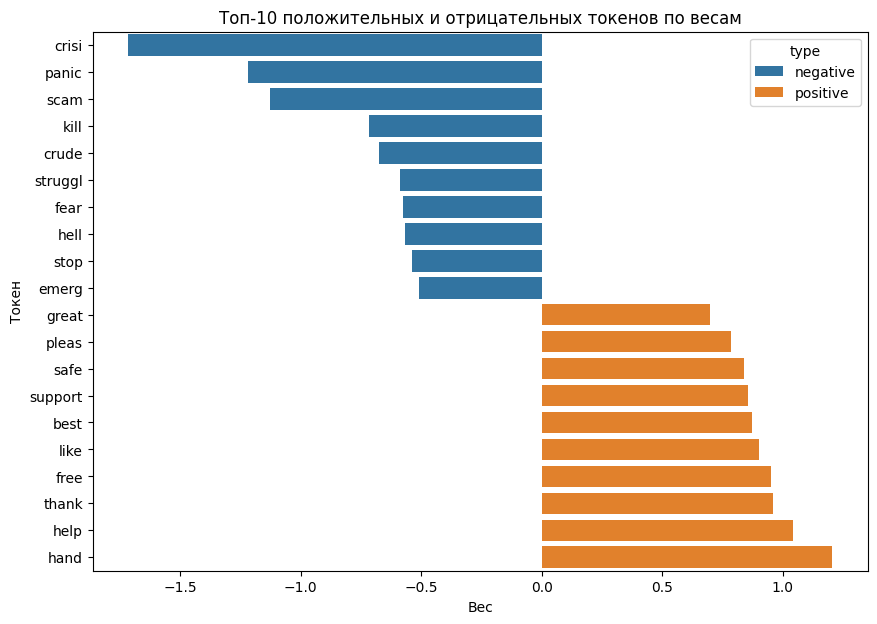

In [44]:
tokens = np.array(cv_df.get_feature_names_out())
weights = model_scaled.coef_[0]

top_positive_idx = np.argsort(weights)[-10:]
top_negative_idx = np.argsort(weights)[:10]

top_tokens = pd.DataFrame({
    'token': np.concatenate([tokens[top_negative_idx], tokens[top_positive_idx]]),
    'weight': np.concatenate([weights[top_negative_idx], weights[top_positive_idx]]),
    'type': ['negative'] * 10 + ['positive'] * 10
})

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_tokens,
    x='weight',
    y='token',
    hue='type'
)

plt.title('Топ-10 положительных и отрицательных токенов по весам')
plt.xlabel('Вес')
plt.ylabel('Токен')
plt.show()

**Ответ:** Веса логистической регрессии стали сопоставимыми после масштабирования признаков. теперь можно выделить наиболее важные токены. Токены с отрицательными весами связаны с негативным классом и отражают тревожные, кризисные или опасные ситуации. В то время каак токены с положительными весами связаны с позитивным классом и отражают поддержку, помощь и положительные эмоции. Соответственно, модель работает корректно, разграничивает слова на негативные, где кризис и страх, и позитивные, где помощь и поддержка.

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [45]:
cols = ['UserName', 'ScreenName']

for col in cols:
    print(col)
    print('Уникальных значений:', train[col].nunique())
    print('Пропусков:', train[col].isna().sum())
    print(train[col].value_counts().head(10))
    print()

UserName
Уникальных значений: 23410
Пропусков: 0
UserName
28197    1
19651    1
24193    1
19822    1
25946    1
6901     1
40855    1
22623    1
21571    1
14024    1
Name: count, dtype: int64

ScreenName
Уникальных значений: 23410
Пропусков: 0
ScreenName
73149    1
64603    1
69145    1
64774    1
70898    1
51853    1
85807    1
67575    1
66523    1
58976    1
Name: count, dtype: int64



**Ответ:** Данные признаки не полезны для использования, так как у них большое количество уникальных значений и нет пропусков. Можно заметить, что каждое значение встречается всего один раз, значит это по сути идентификаторы пользователей. Такие признаки не помогут выявить закономерности, а даже могут привести к переобучению.

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

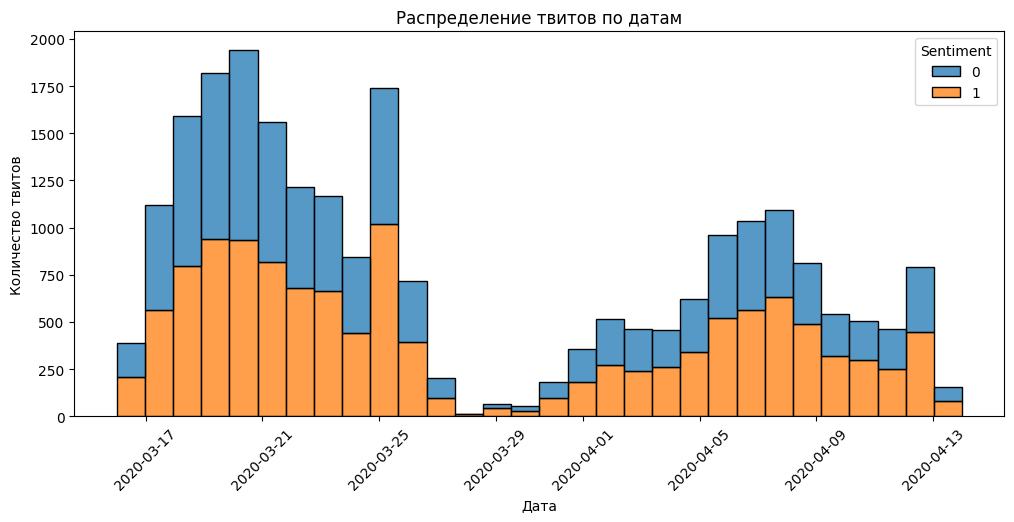

In [46]:
train['TweetAt'] = pd.to_datetime(train['TweetAt'], dayfirst=True)
test['TweetAt'] = pd.to_datetime(test['TweetAt'], dayfirst=True)

plt.figure(figsize=(12, 5))
sns.histplot(
    data=train,
    x='TweetAt',
    hue='Sentiment',
    bins=30,
    multiple='stack'
)

plt.title('Распределение твитов по датам')
plt.xlabel('Дата')
plt.ylabel('Количество твитов')
plt.xticks(rotation=45)
plt.show()

**Ответ:** По гистограмме видно, что распределение твитов по датам неравномерное, то повышенная активность, то спад. Соотношение классов же в разные даты примерно одинаковое, нет какого-то четкого разделения по времени между классами. Можно сказать, что TweetAt не является сильным признаком, но содержит дополнительную информацию. В модели его необходимо дополнительно преобразовать.

Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [47]:
print('Уникальных Location:', train['Location'].nunique())
print('Пропусков:', train['Location'].isna().sum())

train['Location'].value_counts().head(20)

Уникальных Location: 7887
Пропусков: 0


Location
Unknown                    4921
London                      299
London, England             294
United States               291
Washington, DC              227
New York, NY                216
United Kingdom              189
Los Angeles, CA             157
India                       146
UK                          139
Australia                   126
USA                         125
England, United Kingdom     109
Canada                       98
California, USA              95
Global                       92
Chicago, IL                  91
San Francisco, CA            89
Toronto, Ontario             89
New York, USA                75
Name: count, dtype: int64

Признак Location содержит очень большое количество уникальных значений = 7887, и в то же время значительная часть наблюдений относится к категории Unknown. Можно заметить, что одни и те же географические места записаны по-разному (London; London, England; UK; United  Kingdom), это увеличивает количество уникальных значений и разрежает информацию.
Модели трудно использовать такие признаки. Для повышения их полезности требуется предварительная обработка и укрупнение категорий.

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

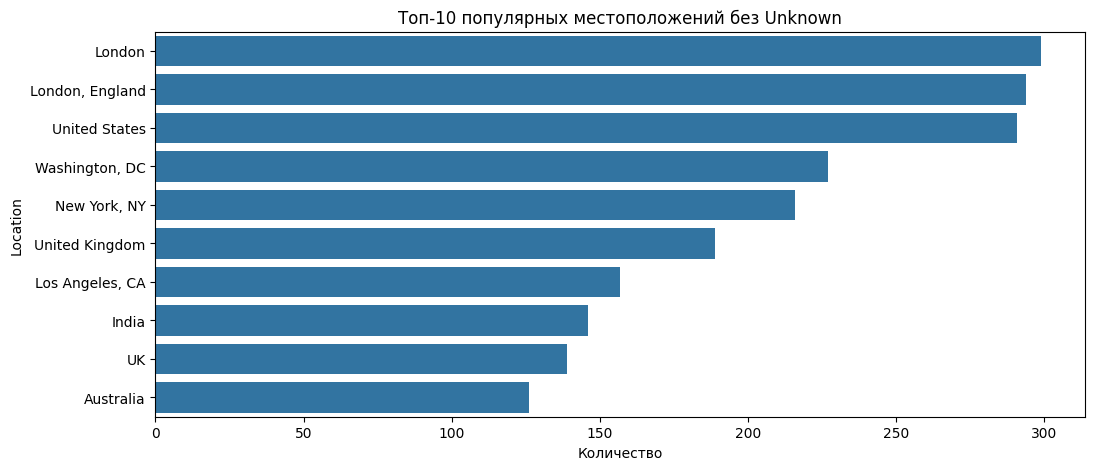

In [48]:
top_locations = (
    train[train['Location'] != 'Unknown']['Location']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title('Топ-10 популярных местоположений без Unknown')
plt.xlabel('Количество')
plt.ylabel('Location')
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [49]:
def get_wider_location(location):
    if pd.isna(location) or location == 'Unknown':
        return 'Unknown'
    
    parts = str(location).split(',')
    return parts[-1].strip()

train['WiderLocation'] = train['Location'].apply(get_wider_location)
test['WiderLocation'] = test['Location'].apply(get_wider_location)

print('Уникальных WiderLocation:', train['WiderLocation'].nunique())

train['WiderLocation'].value_counts().head(20)

Уникальных WiderLocation: 4603


WiderLocation
Unknown           4921
USA                989
England            915
CA                 607
India              544
UK                 404
NY                 397
London             378
United Kingdom     376
Canada             304
United States      302
TX                 270
Australia          263
DC                 246
Ontario            198
FL                 190
Nigeria            167
IL                 158
South Africa       141
PA                 132
Name: count, dtype: int64

После преобразования количество уникальных значений сильно уменьшилось, с 7887 до 4603 категорий, как раз засчет укрупнения категорий. Теперь одинаковые географические регионы частично объединены. Распределение стало более осмысленным, появились часто встречающиеся категории, тем не менее признак всё ещё остается достаточно разреженным, а категория Unknown по-прежнему занимает значительную долю. Можно сказать, что преобразование улучшило структуру признака, но ещё нужна дополнительная фильтрация или отбор наиболее частых значений.

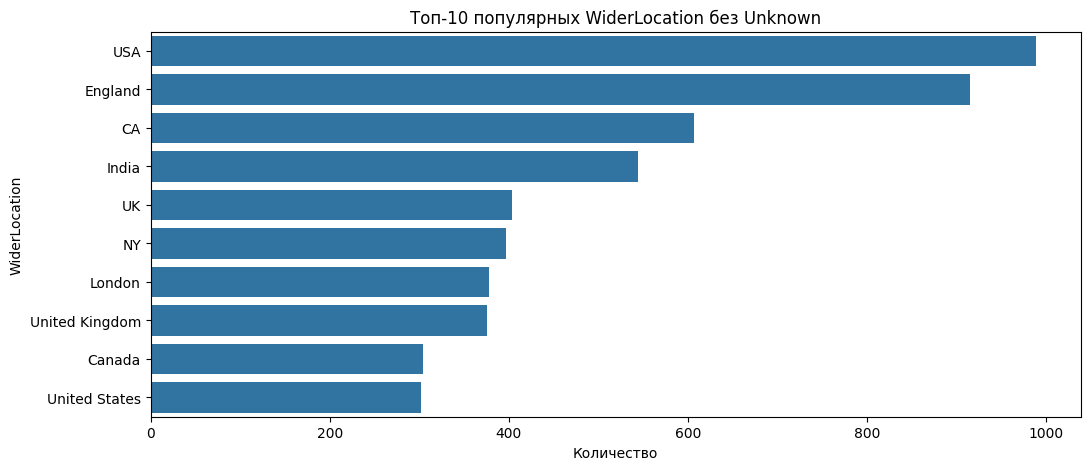

In [50]:
top_wider_locations = (
    train[train['WiderLocation'] != 'Unknown']['WiderLocation']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_wider_locations.values, y=top_wider_locations.index)

plt.title('Топ-10 популярных WiderLocation без Unknown')
plt.xlabel('Количество')
plt.ylabel('WiderLocation')

plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [51]:
from sklearn.preprocessing import OneHotEncoder

wider_counts = train['WiderLocation'].value_counts()
popular_wider_locations = wider_counts[wider_counts > 1].index

print('Значений WiderLocation, которые встречаются больше одного раза:', len(popular_wider_locations))

ohe_location = OneHotEncoder(
    categories=[popular_wider_locations],
    handle_unknown='ignore',
    sparse_output=True
)

X_train_location = ohe_location.fit_transform(train[['WiderLocation']])

print(X_train_location.shape)

Значений WiderLocation, которые встречаются больше одного раза: 989
(23410, 989)


Таких значений получилось 989. В итоге вышла разреженная матрица размера (23410, 989). И для каждого объекта добавлены бинарные признаки, показывающие принадлежность к одной из популярных локаций. Это позволит использовать признак WiderLocation в логистической регрессии, не создавая отдельные столбцы для единичных редких значений.

Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [52]:
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_test_location = ohe_location.transform(test[['WiderLocation']])

X_train_with_location = hstack([X_train_scaled, X_train_location])
X_test_with_location = hstack([X_test_scaled, X_test_location])

model_with_location = LogisticRegression(max_iter=1000, random_state=42)
model_with_location.fit(X_train_with_location, y_train)

train_pred_with_location = model_with_location.predict(X_train_with_location)
test_pred_with_location = model_with_location.predict(X_test_with_location)

print("Без WiderLocation")
print("Train accuracy:", accuracy_score(y_train, train_pred_scaled))
print("Test accuracy:", accuracy_score(y_test, test_pred_scaled))

print("\nС WiderLocation")
print("Train accuracy:", accuracy_score(y_train, train_pred_with_location))
print("Test accuracy:", accuracy_score(y_test, test_pred_with_location))

Без WiderLocation
Train accuracy: 0.9411789833404528
Test accuracy: 0.8410404624277457

С WiderLocation
Train accuracy: 0.9441691584792824
Test accuracy: 0.8399441897548335


**Ответ:** Добавление признака WiderLocation привело к небольшому увеличению на train с 0.9412 до 0.9442. А на test качество немного ухудшилось с 0.8410 до 0.8399. Соответственно, модель начала лучше запоминать обучающую выборку, но не стала лучше обобщать на новые данные, это может говорить о переобучении. Делаю вывод, что признак WiderLocation не оказался полезным.